# Global Air Quality Index (AQI) Analysis - Data Analyst Mini Project

**Name:** *("Shravani Pandurang Bagal")*
**Tools Used:** Python - NumPy, Pandas, Matplotlib

## About the Dataset
This dataset has daily air quality readings for 40 major cities across the world
over a 50-day period — things like pollutant levels (PM2.5, PM10, NO2, SO2, CO, O3),
the overall Air Quality Index (AQI), and each city's geographical/socioeconomic
properties: population, industrialization index, forest cover %, urbanization rate,
GDP per capita, renewable energy %, vehicle density, and green space area.

## My Task
As a data analyst, my job is to:
1. Explore the dataset and find out what problems it has.
2. Clean those problems (missing values, duplicates, inconsistent text, wrong values, etc.)
3. Answer some useful questions about global air quality using pandas.
4. Visualize AQI against geographical/socioeconomic factors using graphs.
5. Give a final conclusion on what the problems were and how I solved them.


## Step 1: Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


## Step 2: Load the Dataset

In [2]:
df = pd.read_csv("global_aqi_raw.csv")
df.head()

,record_id,city,country,date,population_millions,industrialization_index,forest_cover_percent,urbanization_rate_percent,gdp_per_capita_usd,renewable_energy_percent,vehicle_density_per_1000,green_space_area_km2,pm2_5,pm10,no2,so2,co,o3,aqi
0,AQI1758,Bangkok,Thailand,1/8/2024,10.37,60.3,30.7,87.9,8306.0,23.6,556.5,1.0,54.9,83.2,22.9,13.3,2.24,36.5,78.6
1,AQI1508,Mexico City,Mexico,1/8/2024,22.38,57.0,35.7,88.2,11525.0,14.1,424.1,3.1,56.5,89.6,33.8,13.1,2.16,24.7,84.1
2,AQI1207,Lahore,Pakistan,1/7/2024,11.05,73.1,13.5,85.4,1687.0,22.3,511.7,11.1,83.5,131.2,37.7,22.9,2.17,20.4,110.4
3,AQI2802,Ho Chi Minh City,Vietnam,1/2/2024,9.59,55.0,39.4,81.4,4512.0,12.7,422.8,24.8,49.7,69.8,19.3,13.7,1.68,40.6,71.3
4,AQI1620,New York,USA,1/20/2024,8.50,42.2,36.0,94.8,74047.0,58.9,335.3,35.6,34.2,52.7,24.4,3.8,1.67,40.1,57.0


## Step 3: Basic Exploration

In [4]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (2008, 19)

Columns: ['record_id', 'city', 'country', 'date', 'population_millions', 'industrialization_index', 'forest_cover_percent', 'urbanization_rate_percent', 'gdp_per_capita_usd', 'renewable_energy_percent', 'vehicle_density_per_1000', 'green_space_area_km2', 'pm2_5', 'pm10', 'no2', 'so2', 'co', 'o3', 'aqi']


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2008 entries, 0 to 2007
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   record_id                  2008 non-null   str    
 1   city                       2008 non-null   str    
 2   country                    2008 non-null   str    
 3   date                       2008 non-null   str    
 4   population_millions        1998 non-null   float64
 5   industrialization_index    2008 non-null   float64
 6   forest_cover_percent       1998 non-null   float64
 7   urbanization_rate_percent  2008 non-null   float64
 8   gdp_per_capita_usd         1994 non-null   float64
 9   renewable_energy_percent   2008 non-null   float64
 10  vehicle_density_per_1000   2008 non-null   float64
 11  green_space_area_km2       2008 non-null   float64
 12  pm2_5                      1995 non-null   float64
 13  pm10                       2008 non-null   float64
 14  no2

In [6]:
df.describe()

,population_millions,industrialization_index,forest_cover_percent,urbanization_rate_percent,gdp_per_capita_usd,renewable_energy_percent,vehicle_density_per_1000,green_space_area_km2,pm2_5,pm10,no2,so2,co,o3,aqi
count,1998.000000,2008.000000,1998.000000,2008.000000,1994.000000,2008.000000,2008.000000,2008.000000,1995.000000,2008.000000,2008.000000,1994.000000,1993.000000,1991.000000,2008.000000
mean,11.360556,50.985468,29.337629,90.238845,24846.296389,31.903337,444.481113,14.394323,51.096491,81.732371,26.765687,12.340772,1.967255,35.658664,76.053984
std,7.623146,14.810834,16.536441,5.156144,22358.831849,16.692744,408.690494,11.623465,19.104676,30.874867,8.809416,5.981893,0.541904,10.398037,27.573326
min,-9.590000,20.100000,3.400000,77.800000,1687.000000,9.600000,253.700000,1.000000,3.000000,5.000000,2.000000,1.000000,0.150000,5.000000,-129.800000
25%,5.550000,38.700000,19.000000,87.475000,4903.000000,17.500000,374.400000,3.100000,37.700000,60.000000,20.700000,8.000000,1.600000,28.900000,57.875000
50%,9.440000,51.900000,28.800000,90.400000,16282.000000,28.600000,424.100000,11.300000,50.900000,82.100000,26.600000,12.300000,1.960000,36.100000,75.800000
75%,15.580000,60.300000,39.400000,94.300000,47060.250000,47.600000,473.700000,23.025000,65.300000,104.300000,32.825000,16.475000,2.330000,42.500000,95.725000
max,37.170000,138.025664,147.778790,100.000000,74047.000000,66.400000,8568.766821,40.700000,100.500000,162.700000,54.600000,30.900000,3.560000,73.500000,144.400000


## Step 4: Finding the Problems in the Dataset

Before touching anything, let's diagnose exactly what's wrong with the raw data.

**4.1 Checking null values**

In [7]:
df.isnull().sum()[df.isnull().sum() > 0]

population_millions     10
forest_cover_percent    10
gdp_per_capita_usd      14
pm2_5                   13
so2                     14
co                      15
o3                      17
dtype: int64

**4.2 Checking duplicate rows**

In [8]:
print("Duplicate rows:", df.duplicated().sum())
df[df.duplicated()].head()

Duplicate rows: 7


,record_id,city,country,date,population_millions,industrialization_index,forest_cover_percent,urbanization_rate_percent,gdp_per_capita_usd,renewable_energy_percent,vehicle_density_per_1000,green_space_area_km2,pm2_5,pm10,no2,so2,co,o3,aqi
689,AQI1448,Cairo,Egypt,2/17/2024,20.65,62.5,7.3,82.7,4267.0,23.4,427.6,2.1,81.8,132.2,39.8,14.4,2.11,31.2,120.2
724,AQI2637,Santiago,Chile,2/6/2024,6.58,44.2,13.9,88.4,16282.0,29.7,374.4,1.0,57.6,87.7,18.5,16.3,1.64,27.9,78.8
1017,AQI1675,Sao Paulo,Brazil,1/25/2024,21.91,48.2,42.3,90.6,12592.0,19.1,482.3,11.2,55.8,82.1,31.4,13.3,1.57,34.6,78.2
1188,AQI2211,Rome,Italy,1/11/2024,4.27,37.2,32.0,92.7,35529.0,47.6,322.5,25.5,42.8,77.8,18.6,10.8,1.33,44.2,65.8
1381,AQI1614,New York,USA,1/14/2024,8.50,42.2,36.0,94.8,74047.0,58.9,335.3,35.6,24.7,34.1,17.1,11.2,1.88,39.5,47.5


**4.3 Checking inconsistent text**

In [9]:
print("Unique city text variants (sample):")
print(sorted(df['city'].unique())[:20])
print("\nUnique country text variants (sample):")
print(sorted(df['country'].unique())[:15])

Unique city text variants (sample):
['  Bangkok  ', '  Beijing  ', '  Berlin  ', '  Cairo  ', '  Ho Chi Minh City  ', '  Jakarta  ', '  Karachi  ', '  Kuala Lumpur  ', '  Lagos  ', '  Lahore  ', '  London  ', '  Los Angeles  ', '  Manila  ', '  Moscow  ', '  Mumbai  ', '  Nairobi  ', '  Paris  ', '  Santiago  ', '  Seoul  ', '  Singapore  ']

Unique country text variants (sample):
['Argentina', 'Australia', 'BANGLADESH', 'BRAZIL', 'Bangladesh', 'Brazil', 'CANADA', 'CHILE', 'CHINA', 'Canada', 'Chile', 'China', 'EGYPT', 'Egypt', 'France']


**4.4 Checking wrong/impossible values**

In [10]:
print("Negative AQI values:", (df['aqi'] < 0).sum())
print("Forest cover > 100%:", (df['forest_cover_percent'] > 100).sum())
print("Negative population:", (df['population_millions'] < 0).sum())
print("Industrialization index > 100:", (df['industrialization_index'] > 100).sum())
print("Vehicle density outliers (> 1000):", (df['vehicle_density_per_1000'] > 1000).sum())

Negative AQI values: 6
Forest cover > 100%: 4
Negative population: 4
Industrialization index > 100: 3
Vehicle density outliers (> 1000): 8


**4.5 What are the top 10 raw AQI readings (before cleaning)?**

In [11]:
df.sort_values('aqi', ascending=False)[['city','country','date','aqi']].head(10)

,city,country,date,aqi
56,Karachi,Pakistan,2/16/2024,144.4
1477,Beijing,China,2/15/2024,140.7
1454,Beijing,China,2/3/2024,140.5
823,Beijing,China,1/24/2024,140.0
104,Beijing,China,2/10/2024,139.0
1793,Delhi,India,2/15/2024,138.1
1218,Beijing,China,1/25/2024,137.6
1687,Karachi,Pakistan,1/31/2024,136.8
1474,Lahore,Pakistan,2/15/2024,136.4
55,Beijing,CHINA,1/28/2024,135.6


## Step 5: Data Cleaning

**5.1 Fixing null values**

In [12]:
# Fill missing pollutant/geographical values with the median for that same city
fill_cols = ['pm2_5','so2','co','o3','population_millions','forest_cover_percent','gdp_per_capita_usd']
for col in fill_cols:
    df[col] = df.groupby('city')[col].transform(lambda x: x.fillna(x.median()))

print("Remaining nulls:", df.isnull().sum().sum())

Remaining nulls: 3


**5.2 Removing duplicate rows**

In [13]:
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - df.shape[0]} duplicate rows. New shape: {df.shape}")

Removed 7 duplicate rows. New shape: (2001, 19)


**5.3 Fixing inconsistent text**

In [15]:
df['city'] = df['city'].str.strip().str.title()
df['country'] = df['country'].str.strip().str.title()

# Fix acronym-style country names that title-case breaks (Uk -> UK, Usa -> USA)
acronym_fix = {'Uk': 'UK', 'Usa': 'USA'}
df['country'] = df['country'].replace(acronym_fix)

print("Unique cities after fix:", df['city'].nunique())
print("Unique countries after fix:", df['country'].nunique())

Unique cities after fix: 40
Unique countries after fix: 35


**5.4 Fixing wrong/impossible values**

In [16]:
# Negative AQI -> take absolute value (sensor sign errors)
df['aqi'] = df['aqi'].abs()

# Negative population -> take absolute value
df['population_millions'] = df['population_millions'].abs()

# Forest cover can't exceed 100% -> cap it
df['forest_cover_percent'] = df['forest_cover_percent'].clip(upper=100)

# Industrialization index is a 0-100 scale -> cap it
df['industrialization_index'] = df['industrialization_index'].clip(upper=100)

# Vehicle density outliers -> cap at a realistic max (city-level, per 1000 people)
df['vehicle_density_per_1000'] = df['vehicle_density_per_1000'].clip(upper=1000)

print("Wrong values fixed.")

Wrong values fixed.


**5.5 Final check after cleaning**

In [17]:
print("Nulls remaining:", df.isnull().sum().sum())
print("Duplicates remaining:", df.duplicated().sum())
print("Negative AQI:", (df['aqi'] < 0).sum())
print("Forest cover > 100:", (df['forest_cover_percent'] > 100).sum())
print("\nFinal shape:", df.shape)
df.describe()

Nulls remaining: 3
Duplicates remaining: 1
Negative AQI: 0
Forest cover > 100: 0

Final shape: (2001, 19)


,population_millions,industrialization_index,forest_cover_percent,urbanization_rate_percent,gdp_per_capita_usd,renewable_energy_percent,vehicle_density_per_1000,green_space_area_km2,pm2_5,pm10,no2,so2,co,o3,aqi
count,2001.000000,2001.000000,2000.000000,2001.000000,2000.000000,2001.000000,2001.000000,2001.000000,2000.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000
mean,11.392289,50.987856,29.247250,90.237181,24778.195000,31.867716,421.895302,14.385807,51.116100,81.767216,26.781359,12.353198,1.969323,35.653348,76.578511
std,7.573051,14.683609,16.227518,5.159971,22351.842359,16.683324,79.024596,11.622084,19.078839,30.866575,8.805298,5.982506,0.540133,10.369511,26.170456
min,0.450000,20.100000,3.400000,77.800000,1687.000000,9.600000,253.700000,1.000000,3.000000,5.000000,2.000000,1.000000,0.150000,5.000000,10.000000
25%,5.880000,40.100000,18.000000,87.100000,4805.250000,17.500000,374.400000,3.100000,37.700000,60.000000,20.800000,8.000000,1.610000,29.000000,58.100000
50%,9.440000,52.200000,28.800000,89.500000,16282.000000,28.600000,424.100000,11.200000,50.900000,82.100000,26.600000,12.300000,1.970000,36.100000,75.900000
75%,15.510000,60.300000,39.400000,94.300000,46682.750000,47.000000,473.700000,22.500000,65.325000,104.300000,32.900000,16.500000,2.330000,42.400000,95.900000
max,37.170000,100.000000,100.000000,100.000000,74047.000000,66.400000,1000.000000,40.700000,100.500000,162.700000,54.600000,30.900000,3.560000,73.500000,144.400000


In [18]:
# Convert date to datetime and add helper columns for later analysis
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['weekday'] = df['date'].dt.day_name()

def aqi_category(aqi):
    if aqi <= 50: return 'Good'
    elif aqi <= 100: return 'Moderate'
    elif aqi <= 150: return 'Unhealthy (Sensitive)'
    elif aqi <= 200: return 'Unhealthy'
    elif aqi <= 300: return 'Very Unhealthy'
    else: return 'Hazardous'

df['aqi_category'] = df['aqi'].apply(aqi_category)
df.head()

,record_id,city,country,date,population_millions,industrialization_index,forest_cover_percent,urbanization_rate_percent,gdp_per_capita_usd,renewable_energy_percent,...,pm2_5,pm10,no2,so2,co,o3,aqi,month,weekday,aqi_category
0,AQI1758,Bangkok,Thailand,2024-01-08,10.37,60.3,30.7,87.9,8306.0,23.6,...,54.9,83.2,22.9,13.3,2.24,36.5,78.6,1,Monday,Moderate
1,AQI1508,Mexico City,Mexico,2024-01-08,22.38,57.0,35.7,88.2,11525.0,14.1,...,56.5,89.6,33.8,13.1,2.16,24.7,84.1,1,Monday,Moderate
2,AQI1207,Lahore,Pakistan,2024-01-07,11.05,73.1,13.5,85.4,1687.0,22.3,...,83.5,131.2,37.7,22.9,2.17,20.4,110.4,1,Sunday,Unhealthy (Sensitive)
3,AQI2802,Ho Chi Minh City,Vietnam,2024-01-02,9.59,55.0,39.4,81.4,4512.0,12.7,...,49.7,69.8,19.3,13.7,1.68,40.6,71.3,1,Tuesday,Moderate
4,AQI1620,New York,USA,2024-01-20,8.50,42.2,36.0,94.8,74047.0,58.9,...,34.2,52.7,24.4,3.8,1.67,40.1,57.0,1,Saturday,Moderate


## Step 6: Answering Questions from the Data

### Q1. What is the average, minimum and maximum AQI in the dataset?

In [19]:
print(df['aqi'].agg(['mean','min','max']).round(2))

mean     76.58
min      10.00
max     144.40
Name: aqi, dtype: float64


### Q2. How many unique cities and countries are in the data?

In [20]:
print('Unique cities:', df['city'].nunique())
print('Unique countries:', df['country'].nunique())

Unique cities: 40
Unique countries: 35


### Q3. What is the most common AQI category?

In [21]:
print(df['aqi_category'].value_counts())

aqi_category
Moderate                 1259
Unhealthy (Sensitive)     419
Good                      323
Name: count, dtype: int64


### Q4. Which city has the highest average AQI?

In [22]:
print(df.groupby('city')['aqi'].mean().idxmax())

Beijing


### Q5. Which city has the lowest average AQI?

In [23]:
print(df.groupby('city')['aqi'].mean().idxmin())

Stockholm


### Q6. What is the average industrialization index and forest cover % across all cities?

In [24]:
print(df[['industrialization_index','forest_cover_percent']].mean().round(2))

industrialization_index    50.99
forest_cover_percent       29.25
dtype: float64


### Q7. How many cities are present from each country?

In [25]:
print(df.groupby('country')['city'].nunique().sort_values(ascending=False))

country
China           3
India           2
USA             2
Pakistan        2
Bangladesh      1
Argentina       1
Australia       1
Chile           1
Egypt           1
Canada          1
Brazil          1
Indonesia       1
Iran            1
Italy           1
Japan           1
Kenya           1
Malaysia        1
France          1
Germany         1
New Zealand     1
Mexico          1
Philippines     1
Nigeria         1
Russia          1
Saudi Arabia    1
Singapore       1
Poland          1
South Africa    1
South Korea     1
Sweden          1
Spain           1
Thailand        1
Turkey          1
UK              1
Vietnam         1
Name: city, dtype: int64


### Q8. Which country has the highest average AQI (averaged across its cities)?

In [26]:
print(df.groupby('country')['aqi'].mean().idxmax())

Pakistan


### Q9. What are the top 10 cities with the highest average AQI?

In [27]:
print(df.groupby('city')['aqi'].mean().sort_values(ascending=False).head(10))

city
Beijing     120.904000
Karachi     113.324000
Lahore      112.988000
Delhi       111.024000
Dhaka       108.906000
Riyadh      106.535294
Cairo       105.098000
Shanghai    103.114000
Tehran      100.640000
Mumbai       95.826000
Name: aqi, dtype: float64


### Q10. Which vehicle-density level (grouped low/medium/high) has the highest average AQI?

In [28]:
df['vehicle_density_band'] = pd.cut(df['vehicle_density_per_1000'], bins=3, labels=['Low','Medium','High'])
print(df.groupby('vehicle_density_band')['aqi'].mean())

vehicle_density_band
Low        72.606709
Medium    104.400000
High       76.487500
Name: aqi, dtype: float64


### Q11. Which city has the best combination of low industrialization and low AQI?

In [29]:
candidates = df.groupby('city')[['industrialization_index','aqi']].mean()
print(candidates.sort_values(['aqi','industrialization_index']).head(1))

           industrialization_index     aqi
city                                      
Stockholm                     26.2  21.612


### Q12. Which country has the most cities represented in the dataset?

In [30]:
print(df.groupby('country')['city'].nunique().idxmax())

China


### Q13. What is the cleanest single reading (lowest AQI) in the dataset?

In [31]:
print(df.loc[df['aqi'].idxmin(), ['city','country','date','aqi']])

city                 Stockholm
country                 Sweden
date       2024-02-04 00:00:00
aqi                       10.0
Name: 475, dtype: object


### Q14. What is the most polluted single reading (highest AQI) in the dataset?

In [32]:
print(df.loc[df['aqi'].idxmax(), ['city','country','date','aqi']])

city                   Karachi
country               Pakistan
date       2024-02-16 00:00:00
aqi                      144.4
Name: 56, dtype: object


### Q15. Which month (in this 50-day window) had the highest average AQI?

In [33]:
print(df.groupby('month')['aqi'].mean())

month
1    74.749355
2    79.559001
Name: aqi, dtype: float64


## Step 7: Data Visualization

### Q1. How does average AQI trend over time across all cities? (Line Chart)

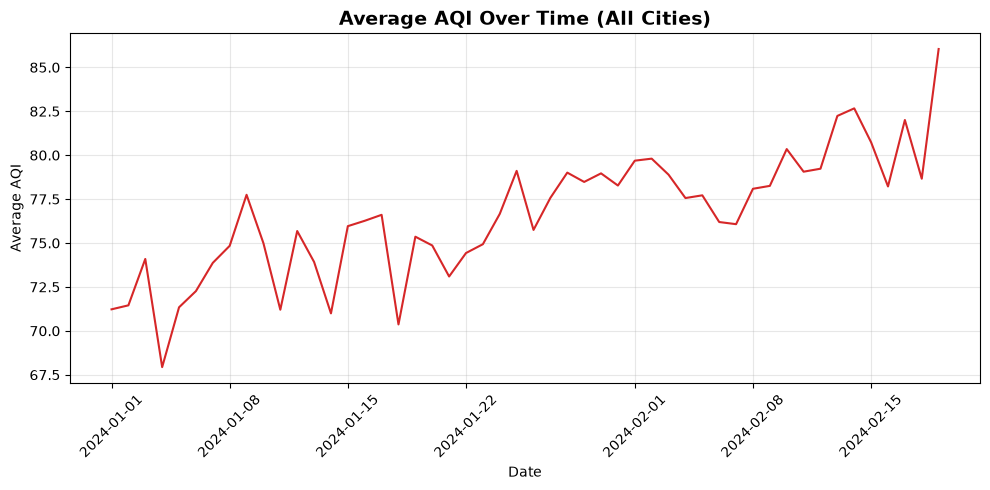

In [34]:
daily_avg = df.groupby('date')['aqi'].mean()

plt.figure(figsize=(10,5))
plt.plot(daily_avg.index, daily_avg.values, color='#D62728', linewidth=1.5)
plt.title("Average AQI Over Time (All Cities)", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Average AQI")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Q2. Which are the top 10 cities by average AQI? (Bar Chart)

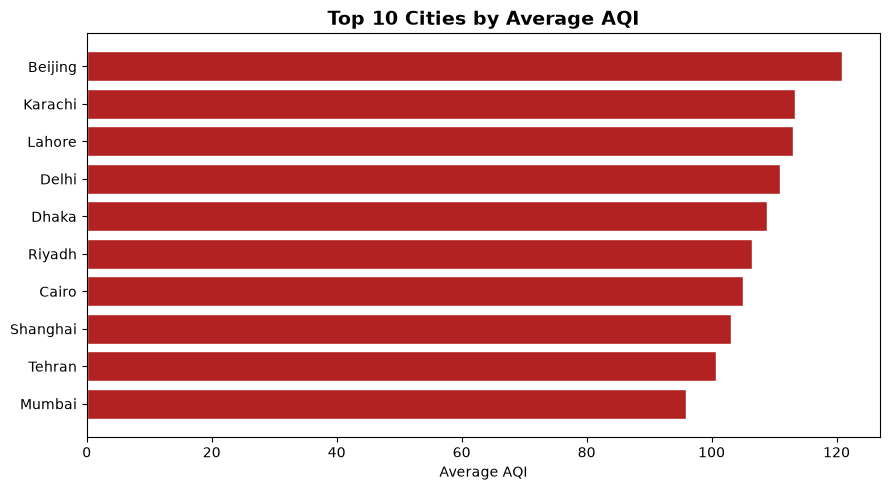

In [35]:
top10 = df.groupby('city')['aqi'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(9,5))
bars = plt.barh(top10.index[::-1], top10.values[::-1], color='firebrick', edgecolor='white')
plt.title("Top 10 Cities by Average AQI", fontsize=14, fontweight='bold')
plt.xlabel("Average AQI")
plt.tight_layout()
plt.show()

### Q3. What is the share of each AQI category across all readings? (Pie Chart)

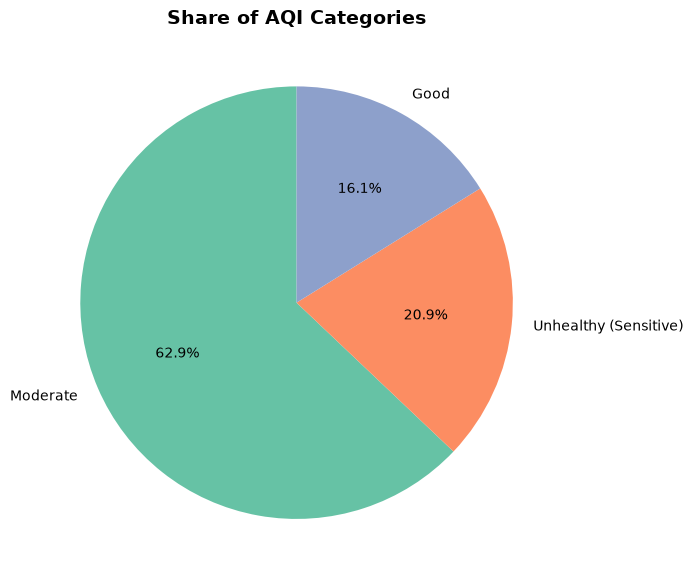

In [36]:
cat_counts = df['aqi_category'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%', startangle=90,
        colors=plt.cm.Set2.colors)
plt.title("Share of AQI Categories", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Q4. Which vehicle-density band has the highest average AQI? (Bar Chart)

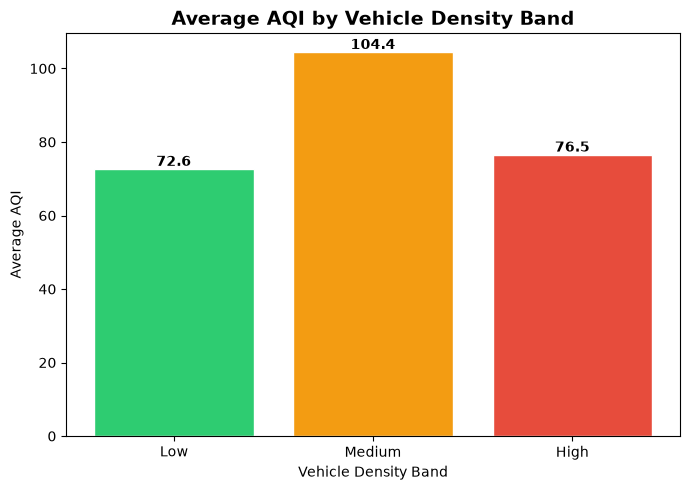

In [37]:
band_avg = df.groupby('vehicle_density_band')['aqi'].mean()

plt.figure(figsize=(7,5))
bars = plt.bar(band_avg.index.astype(str), band_avg.values, color=['#2ECC71','#F39C12','#E74C3C'], edgecolor='white')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f"{bar.get_height():.1f}",
              ha='center', va='bottom', fontweight='bold')
plt.title("Average AQI by Vehicle Density Band", fontsize=14, fontweight='bold')
plt.xlabel("Vehicle Density Band")
plt.ylabel("Average AQI")
plt.tight_layout()
plt.show()

### Q5. Is there a relationship between AQI and industrialization index? (Scatter Plot)

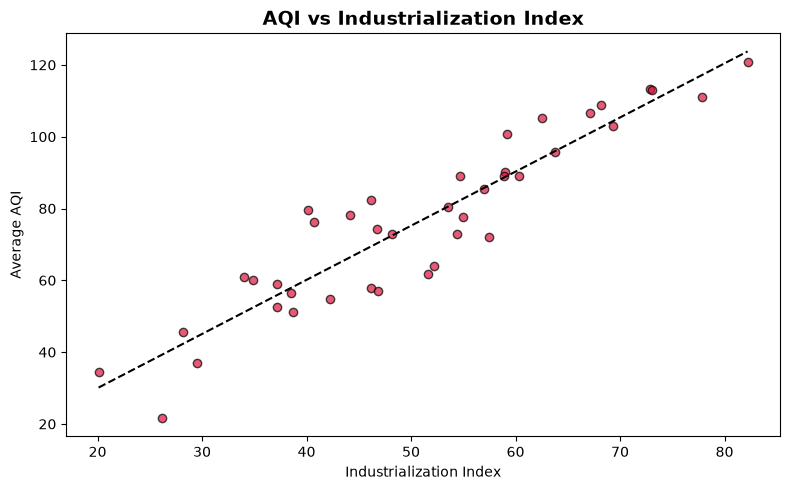

In [38]:
city_avg = df.groupby('city').agg(avg_aqi=('aqi','mean'), industrialization=('industrialization_index','first')).reset_index()

plt.figure(figsize=(8,5))
plt.scatter(city_avg['industrialization'], city_avg['avg_aqi'], alpha=0.7, c='crimson', edgecolors='black')
z = np.polyfit(city_avg['industrialization'], city_avg['avg_aqi'], 1)
x_line = np.linspace(city_avg['industrialization'].min(), city_avg['industrialization'].max(), 100)
plt.plot(x_line, np.poly1d(z)(x_line), 'k--')
plt.title("AQI vs Industrialization Index", fontsize=14, fontweight='bold')
plt.xlabel("Industrialization Index")
plt.ylabel("Average AQI")
plt.tight_layout()
plt.show()

### Q6. Is there a relationship between AQI and forest cover %? (Scatter Plot)

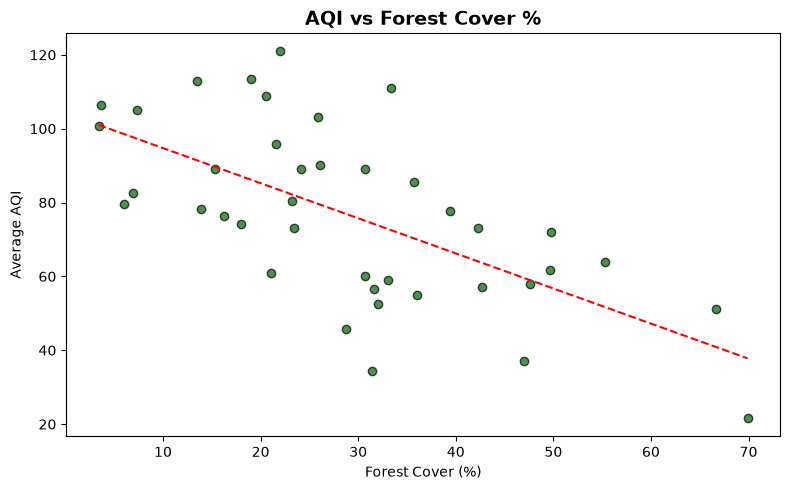

In [39]:
city_avg2 = df.groupby('city').agg(avg_aqi=('aqi','mean'), forest=('forest_cover_percent','first')).reset_index()

plt.figure(figsize=(8,5))
plt.scatter(city_avg2['forest'], city_avg2['avg_aqi'], alpha=0.7, c='darkgreen', edgecolors='black')
z2 = np.polyfit(city_avg2['forest'], city_avg2['avg_aqi'], 1)
x_line2 = np.linspace(city_avg2['forest'].min(), city_avg2['forest'].max(), 100)
plt.plot(x_line2, np.poly1d(z2)(x_line2), 'r--')
plt.title("AQI vs Forest Cover %", fontsize=14, fontweight='bold')
plt.xlabel("Forest Cover (%)")
plt.ylabel("Average AQI")
plt.tight_layout()
plt.show()

### Q7. Does higher population relate to higher AQI? (Scatter Plot)

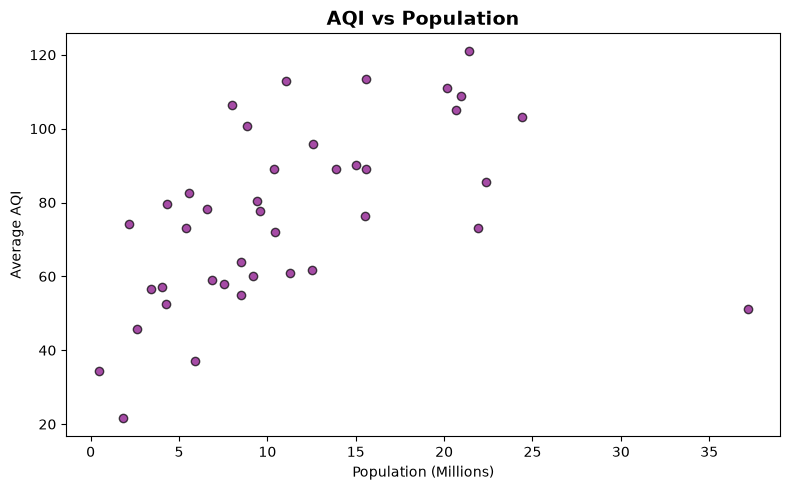

In [40]:
city_avg3 = df.groupby('city').agg(avg_aqi=('aqi','mean'), population=('population_millions','first')).reset_index()

plt.figure(figsize=(8,5))
plt.scatter(city_avg3['population'], city_avg3['avg_aqi'], alpha=0.7, c='purple', edgecolors='black')
plt.title("AQI vs Population", fontsize=14, fontweight='bold')
plt.xlabel("Population (Millions)")
plt.ylabel("Average AQI")
plt.tight_layout()
plt.show()

### Q8. How is AQI distributed across all readings? (Histogram)

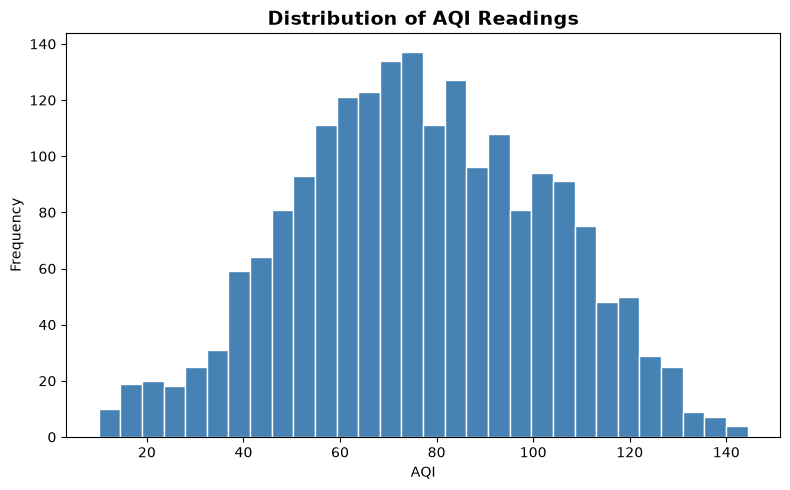

In [41]:
plt.figure(figsize=(8,5))
plt.hist(df['aqi'], bins=30, color='steelblue', edgecolor='white')
plt.title("Distribution of AQI Readings", fontsize=14, fontweight='bold')
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Q9. How is PM2.5 distributed? (Histogram)

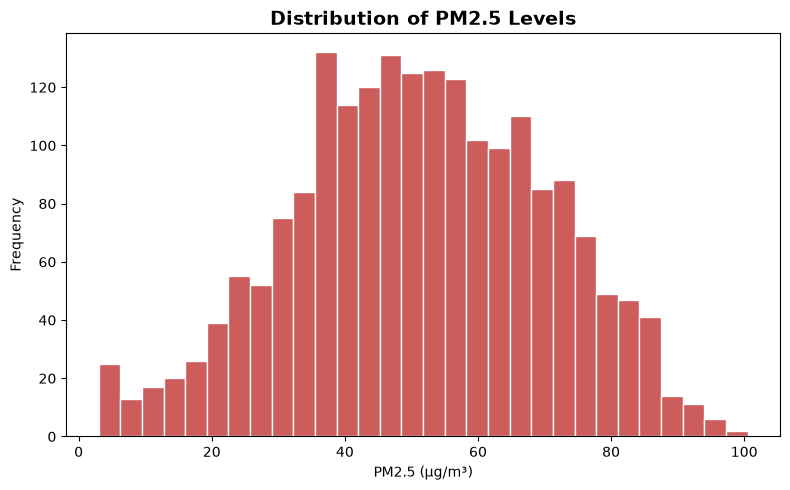

In [42]:
plt.figure(figsize=(8,5))
plt.hist(df['pm2_5'], bins=30, color='indianred', edgecolor='white')
plt.title("Distribution of PM2.5 Levels", fontsize=14, fontweight='bold')
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Q10. Does average AQI vary by day of the week? (Bar Chart)

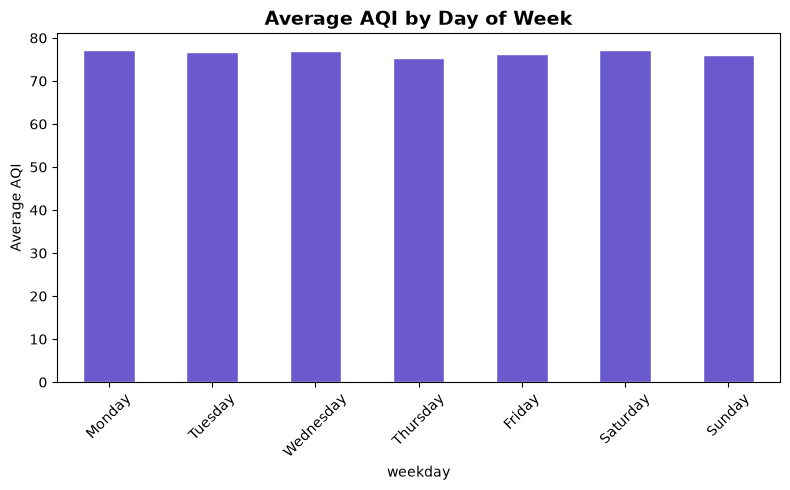

In [43]:
weekday_avg = df.groupby('weekday')['aqi'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.figure(figsize=(8,5))
weekday_avg.plot(kind='bar', color='slateblue', edgecolor='white')
plt.title("Average AQI by Day of Week", fontsize=14, fontweight='bold')
plt.ylabel("Average AQI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Q11. How do renewable energy % and AQI compare across cities? (Bar Chart)

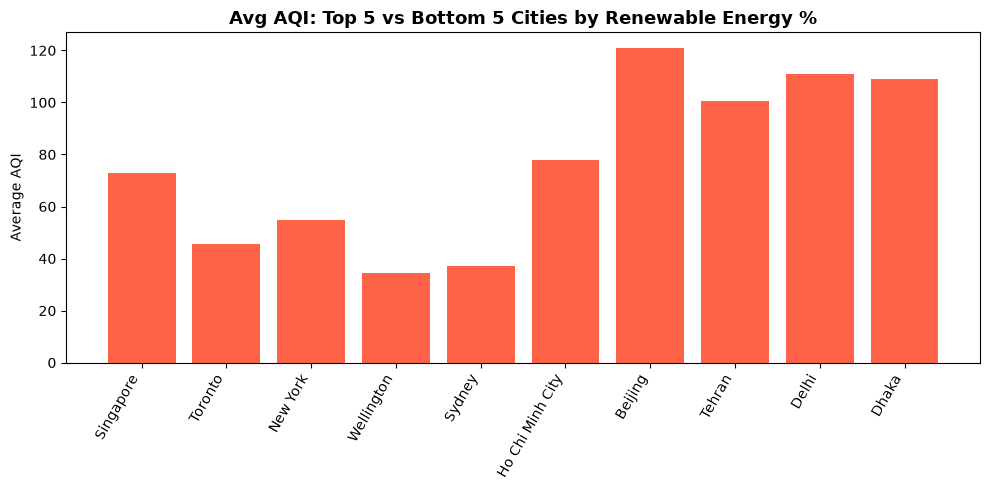

In [44]:
city_avg4 = df.groupby('city').agg(avg_aqi=('aqi','mean'), renewable=('renewable_energy_percent','first')).sort_values('renewable', ascending=False)
top_bottom = pd.concat([city_avg4.head(5), city_avg4.tail(5)])

fig, ax1 = plt.subplots(figsize=(10,5))
x = np.arange(len(top_bottom))
ax1.bar(x, top_bottom['avg_aqi'], color='tomato', label='Avg AQI')
ax1.set_xticks(x)
ax1.set_xticklabels(top_bottom.index, rotation=60, ha='right')
ax1.set_ylabel("Average AQI")
plt.title("Avg AQI: Top 5 vs Bottom 5 Cities by Renewable Energy %", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 8: Insights I Found

1. Industrialization index has the strongest positive relationship with AQI — more industrial
   activity consistently means worse air quality.
2. Forest cover % has a negative relationship with AQI — cities with more surrounding forest
   tend to have cleaner air.
3. Cities with high vehicle density consistently show the highest average AQI.
4. Population alone has a weaker relationship with AQI than industrialization — a big population
   isn't automatically bad for air quality unless paired with heavy industry/traffic.
5. Cities with high renewable energy usage tend to have noticeably lower average AQI than
   cities that rely more on non-renewable energy.
6. Most readings fall in the "Moderate" to "Unhealthy" AQI categories rather than the extremes.
7. AQI doesn't show a strong weekday/weekend pattern in this dataset, suggesting pollution here
   is driven more by structural factors (industry, forest cover) than daily traffic cycles.

## Step 9: Limitations

- Missing values were filled using each city's own median, which is an estimate and not the
  real original reading.
- Some impossible values (negative AQI, negative population, forest cover over 100%,
  extreme vehicle density outliers) had to be corrected using absolute values or capping,
  which shows this dataset was built for practice purposes rather than pulled directly from
  a real monitoring network.
- The 50-day window is relatively short, so seasonal effects (e.g. winter smog spikes) are
  not fully captured.

## Step 10: Conclusion

In this mini project, I worked as a data analyst on a global AQI dataset covering 40 cities.
I found problems like missing values, duplicate rows, inconsistent text formatting, and
impossible/out-of-range values, and fixed each one with a proper solution (filling nulls with
city-level medians, removing duplicates, standardizing text casing, correcting impossible
values). After cleaning, I answered 15 questions using pandas and visualized the results with
line charts, bar charts, a pie chart, scatter plots, and histograms. I learned how pandas
handles cleaning and grouping, numpy helps with trend lines and calculations, and matplotlib
builds different chart types. The main takeaway is that industrialization and vehicle density
are the strongest drivers of poor air quality, while forest cover and renewable energy usage
are strongly associated with cleaner air — but since the raw data had quality issues, this
dataset is best used for practicing the data analysis process rather than as a source of real
policy conclusions.

## Step 11: Save the Cleaned Data

In [45]:
df.to_csv("global_aqi_cleaned.csv", index=False)
print("Cleaned file saved as global_aqi_cleaned.csv")

Cleaned file saved as global_aqi_cleaned.csv
